In [1]:
import sys
import os
sys.path.append(os.path.abspath("../clean_code/"))

In [34]:
from Visualization import generalVisualization
from Visualization import gloveVisuals
from Visualization import mnistVisuals
from Visualization import visualHelpers
from Utilities import config
from Utilities import reader
from Utilities import shuffle

import pickle
import select_landmarks_MI
import importlib
import voltagemap
import setofpoints
import main
import kmeans
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.datasets import fetch_openml

In [64]:
importlib.reload(main)
importlib.reload(reader)
importlib.reload(shuffle)
importlib.reload(mnistVisuals)
importlib.reload(visualHelpers)
importlib.reload(kmeans)

<module 'kmeans' from '/home/avighna/Documents/python/VoltageDimentionalReduction/clean_code/kmeans.py'>

In [77]:
config.params['file_path']= '../../Voltage_Data/glove/glove_2.csv'
config.params['split_char']= ' '
config.params['normalize_vecs'] = True

config.params['max_centroids']= 1000
config.params['init_size']= 5000
config.params['batch_size']= 1000
config.params['kmeans_output']= '../../Voltage_Temp/Results/glove.npy'
config.params['save_data'] = '../../Voltage_Temp/Results/glove_save_data.pkl'
config.params['k']=10
config.params['r']=1
config.params['kmeans_alpha']=0.1
config.params['equalize_centroids']=False
config.params['NoOfLandmarks']=10
config.params['DepthOfLandmarkSearch']=100

In [77]:
data_to_save = main.main()

ERROR! Session/line number was not unique in database. History logging moved to new session 70
Reading CSV file: ../../Voltage_Data/glove/glove_2.csv

Estimated max pairwise distance squared, FAISS) = 2.7614
 Estimated minimum distance squared = 0.0000

Starting a new attempt to select up to 1000 centroids
10 vectors in index after adding initial centroid

number of centroids: 576, max_centroids: 1000

number of centroids: 1000, max_centroids: 1000
Reached maximum number of centroids: 1000

refining vectors
sorted_sizes=[21 17 16 12 12]
too_small=506, rms=0.045350513671759185, finished=True

refining vectors
sorted_sizes=[30 15 14 13 12]
too_small=567, rms=0.041236953629415395, finished=True

refining vectors
sorted_sizes=[23 16 13 13 12]
too_small=623, rms=0.03735840640275506, finished=True

refining vectors
sorted_sizes=[26 21 17 15 14]
too_small=662, rms=0.03437371356206916, finished=True

refining vectors
sorted_sizes=[26 19 19 15 14]
too_small=692, rms=0.032048603271313626, finish


KeyboardInterrupt



KeyboardInterrupt: 

In [ ]:
data_to_save['voltage_map'] = select_landmarks_MI.select_landmarks(data_to_save['all_voltages'])

In [83]:
with open(config.params['save_data'], 'wb') as f:
    pickle.dump(data_to_save, f)

In [5]:
with open(config.params['save_data'], 'rb') as f:
    data_to_save = pickle.load(f)

In [78]:
with open('../../Voltage_Temp/Results/glove/saved_data.pkl', 'rb') as f:
    data_to_save = pickle.load(f)

ERROR! Session/line number was not unique in database. History logging moved to new session 71


In [81]:
voltages = data_to_save['voltage_map']
centroids = data_to_save['centroids']
label_counts = data_to_save['label_counts']
centroid_others = data_to_save['centroid_others']
points = voltages.voltage_array()

Number of point_voltages with no label: 788
Plot saved to mnist_visualization.png


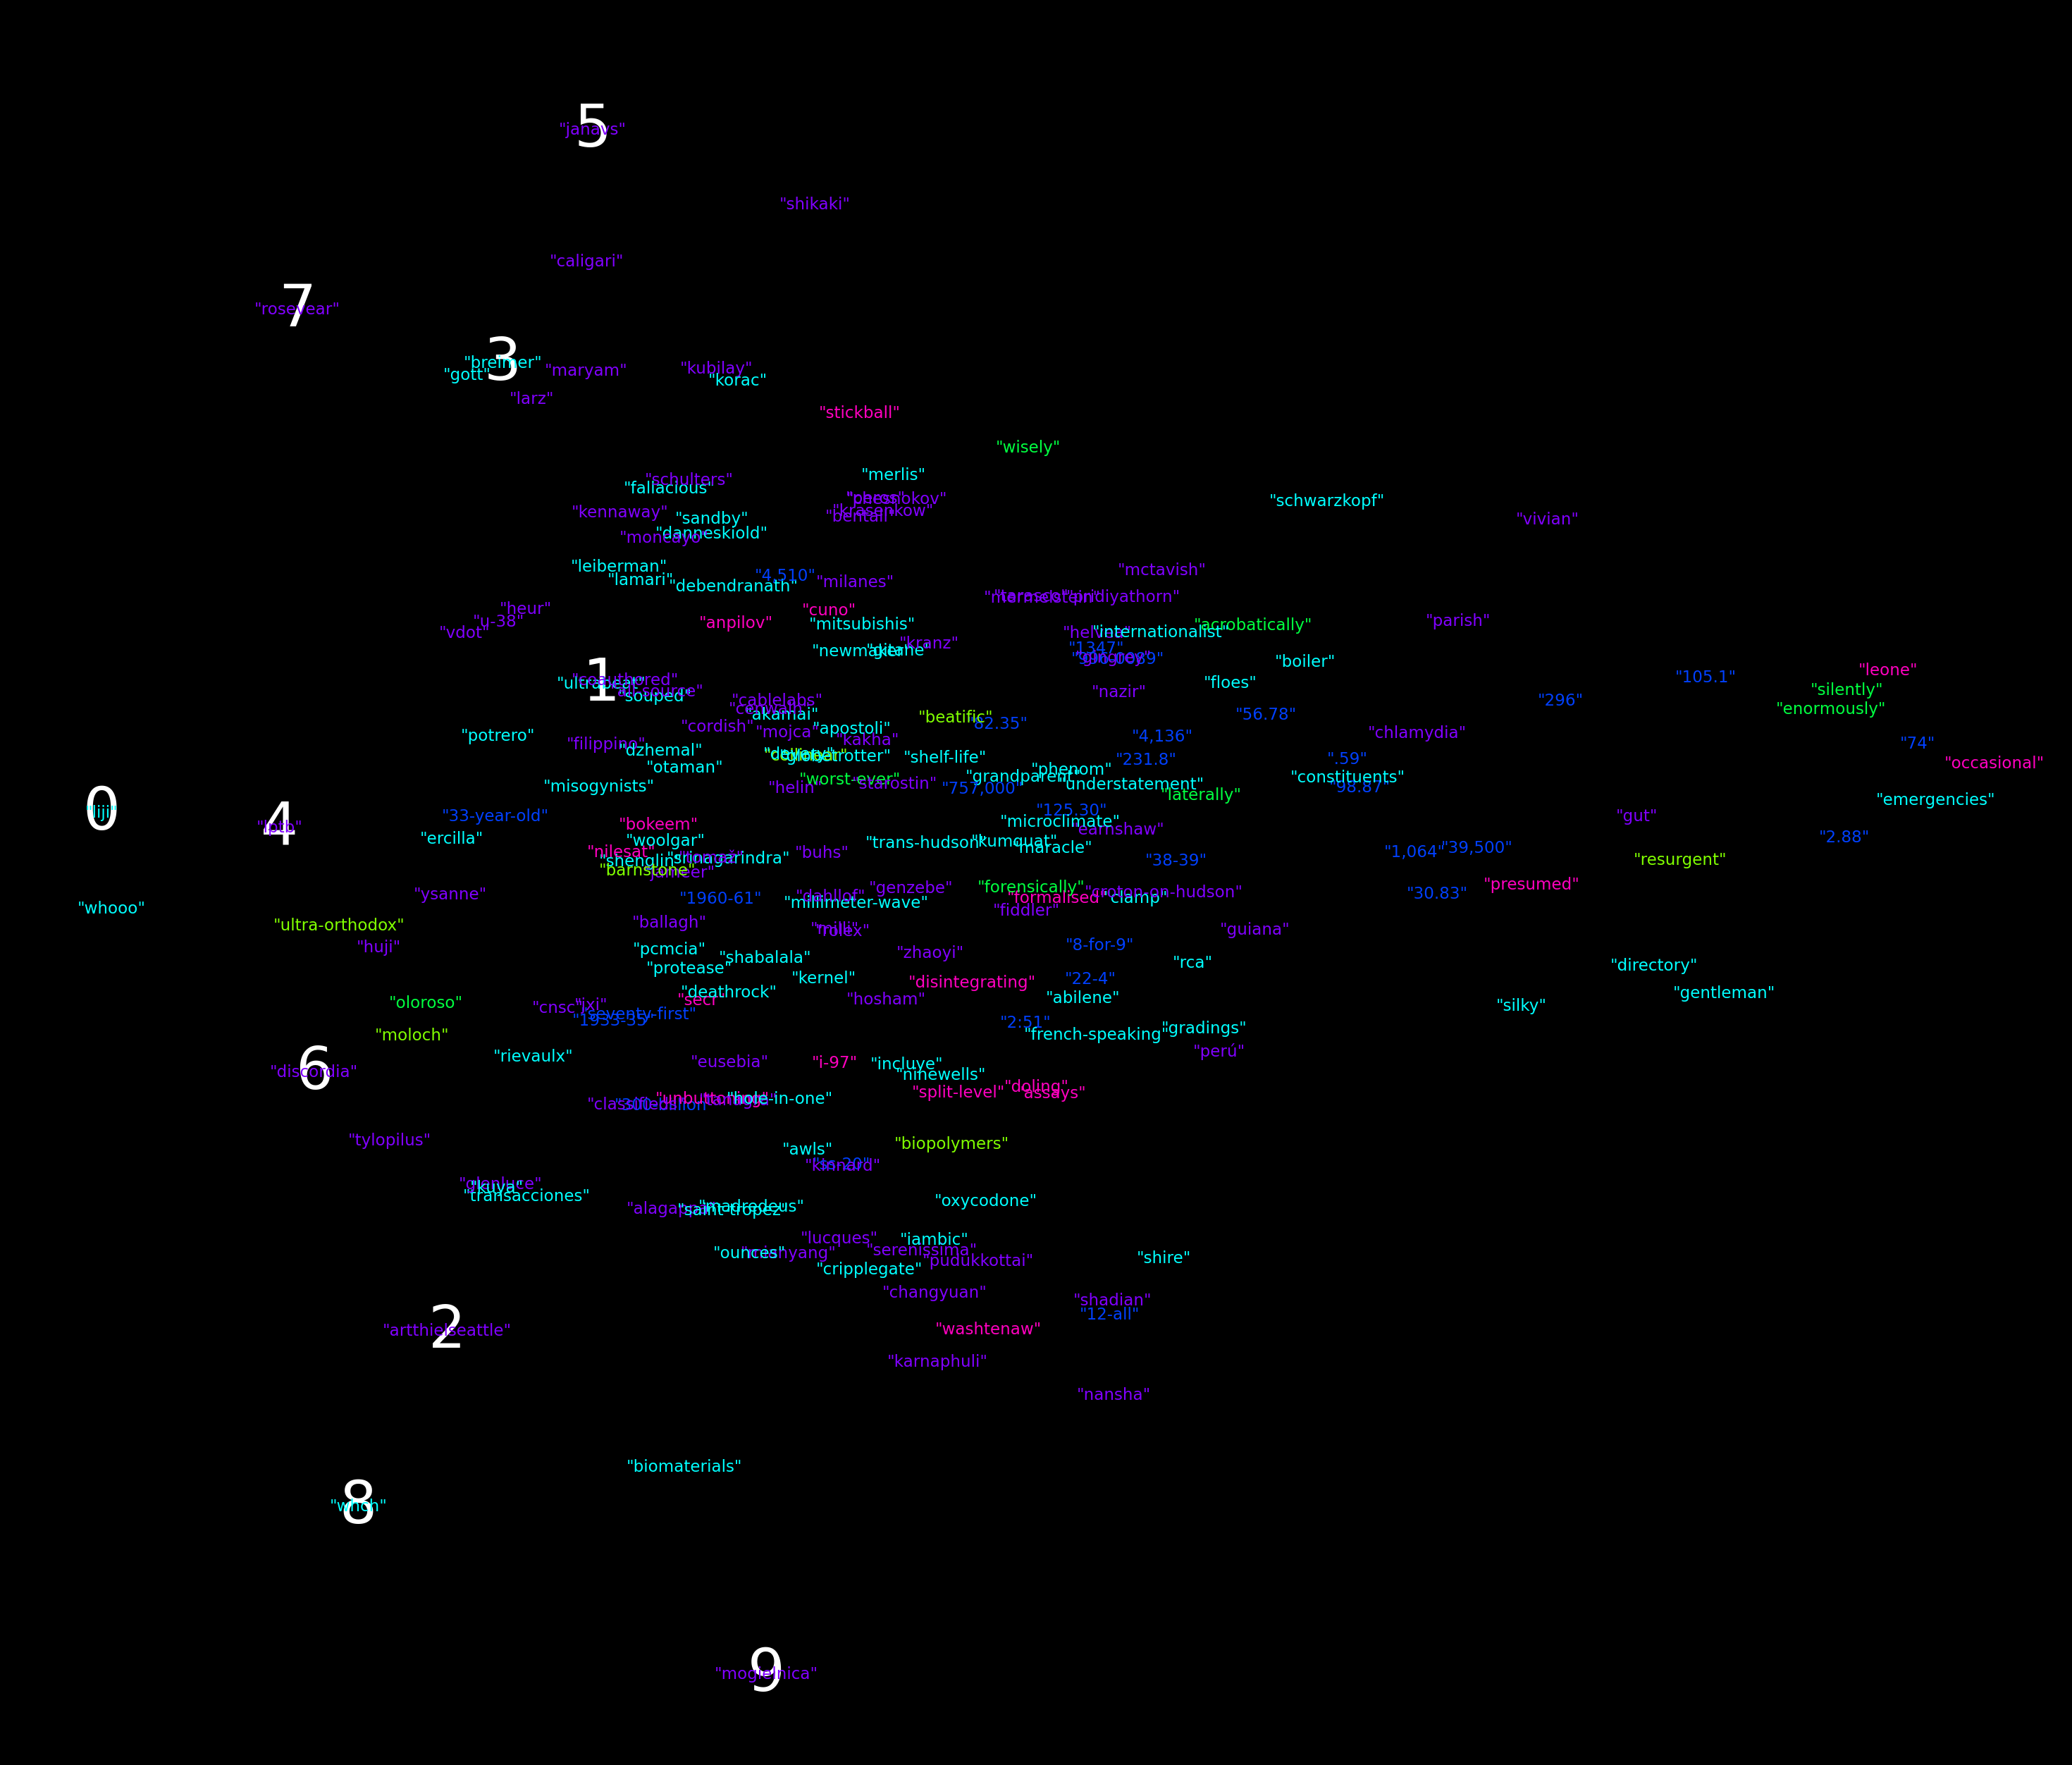

In [82]:
focus_on = np.array([0,1,2,3,4,5,6,7,8,9])
mnistVisuals.plot_landmark_subset(points, centroids, label_counts, focus_on, 
                                  alpha_actual=1, element='word', centroid_others=centroid_others, size_threshold=0, ratio_threshold=0)

Number of point_voltages with no label: 102
Plot saved to mnist_visualization.png


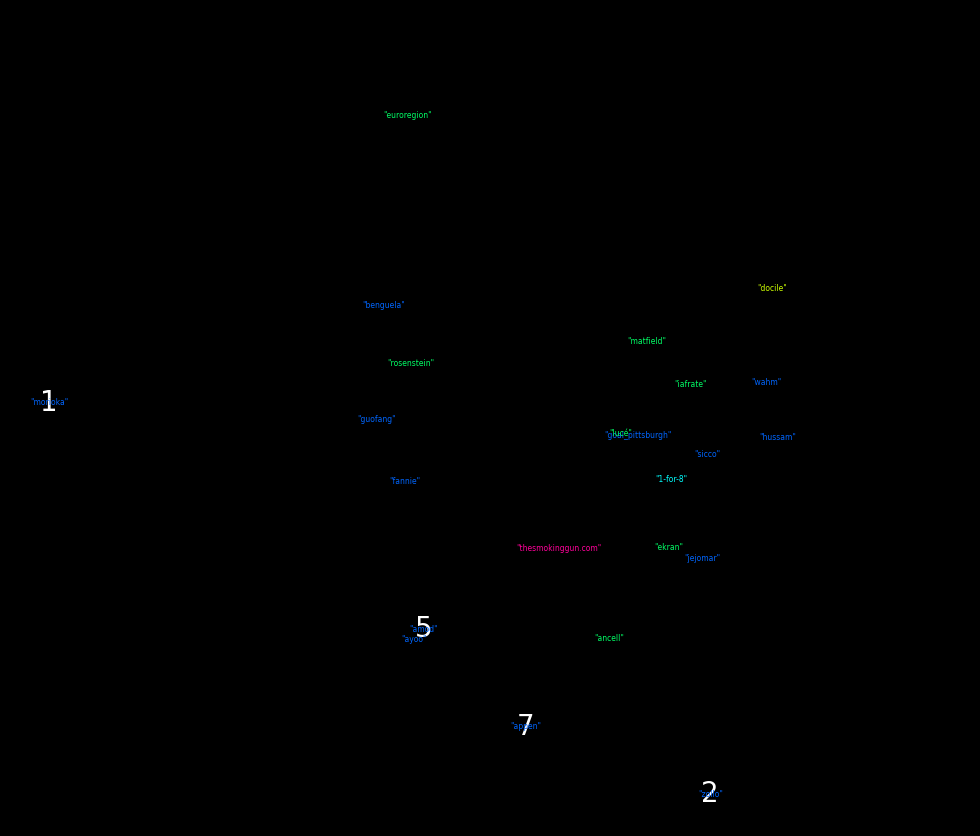

In [51]:
focus_on = np.array([1,2,5,7])
mnistVisuals.plot_landmark_subset(points, centroids, label_counts, focus_on, 
                                  alpha_actual=1, element='word', centroid_others=centroid_others, size_threshold=0, ratio_threshold=0)

Reading CSV file: ../../Voltage_Data/glove/glove_5.csv
<class 'voltagemap.VoltageMap'>
Number of landmarks: 10
Number of point_voltages with no label: 0
Plot saved to mnist_visualization.png


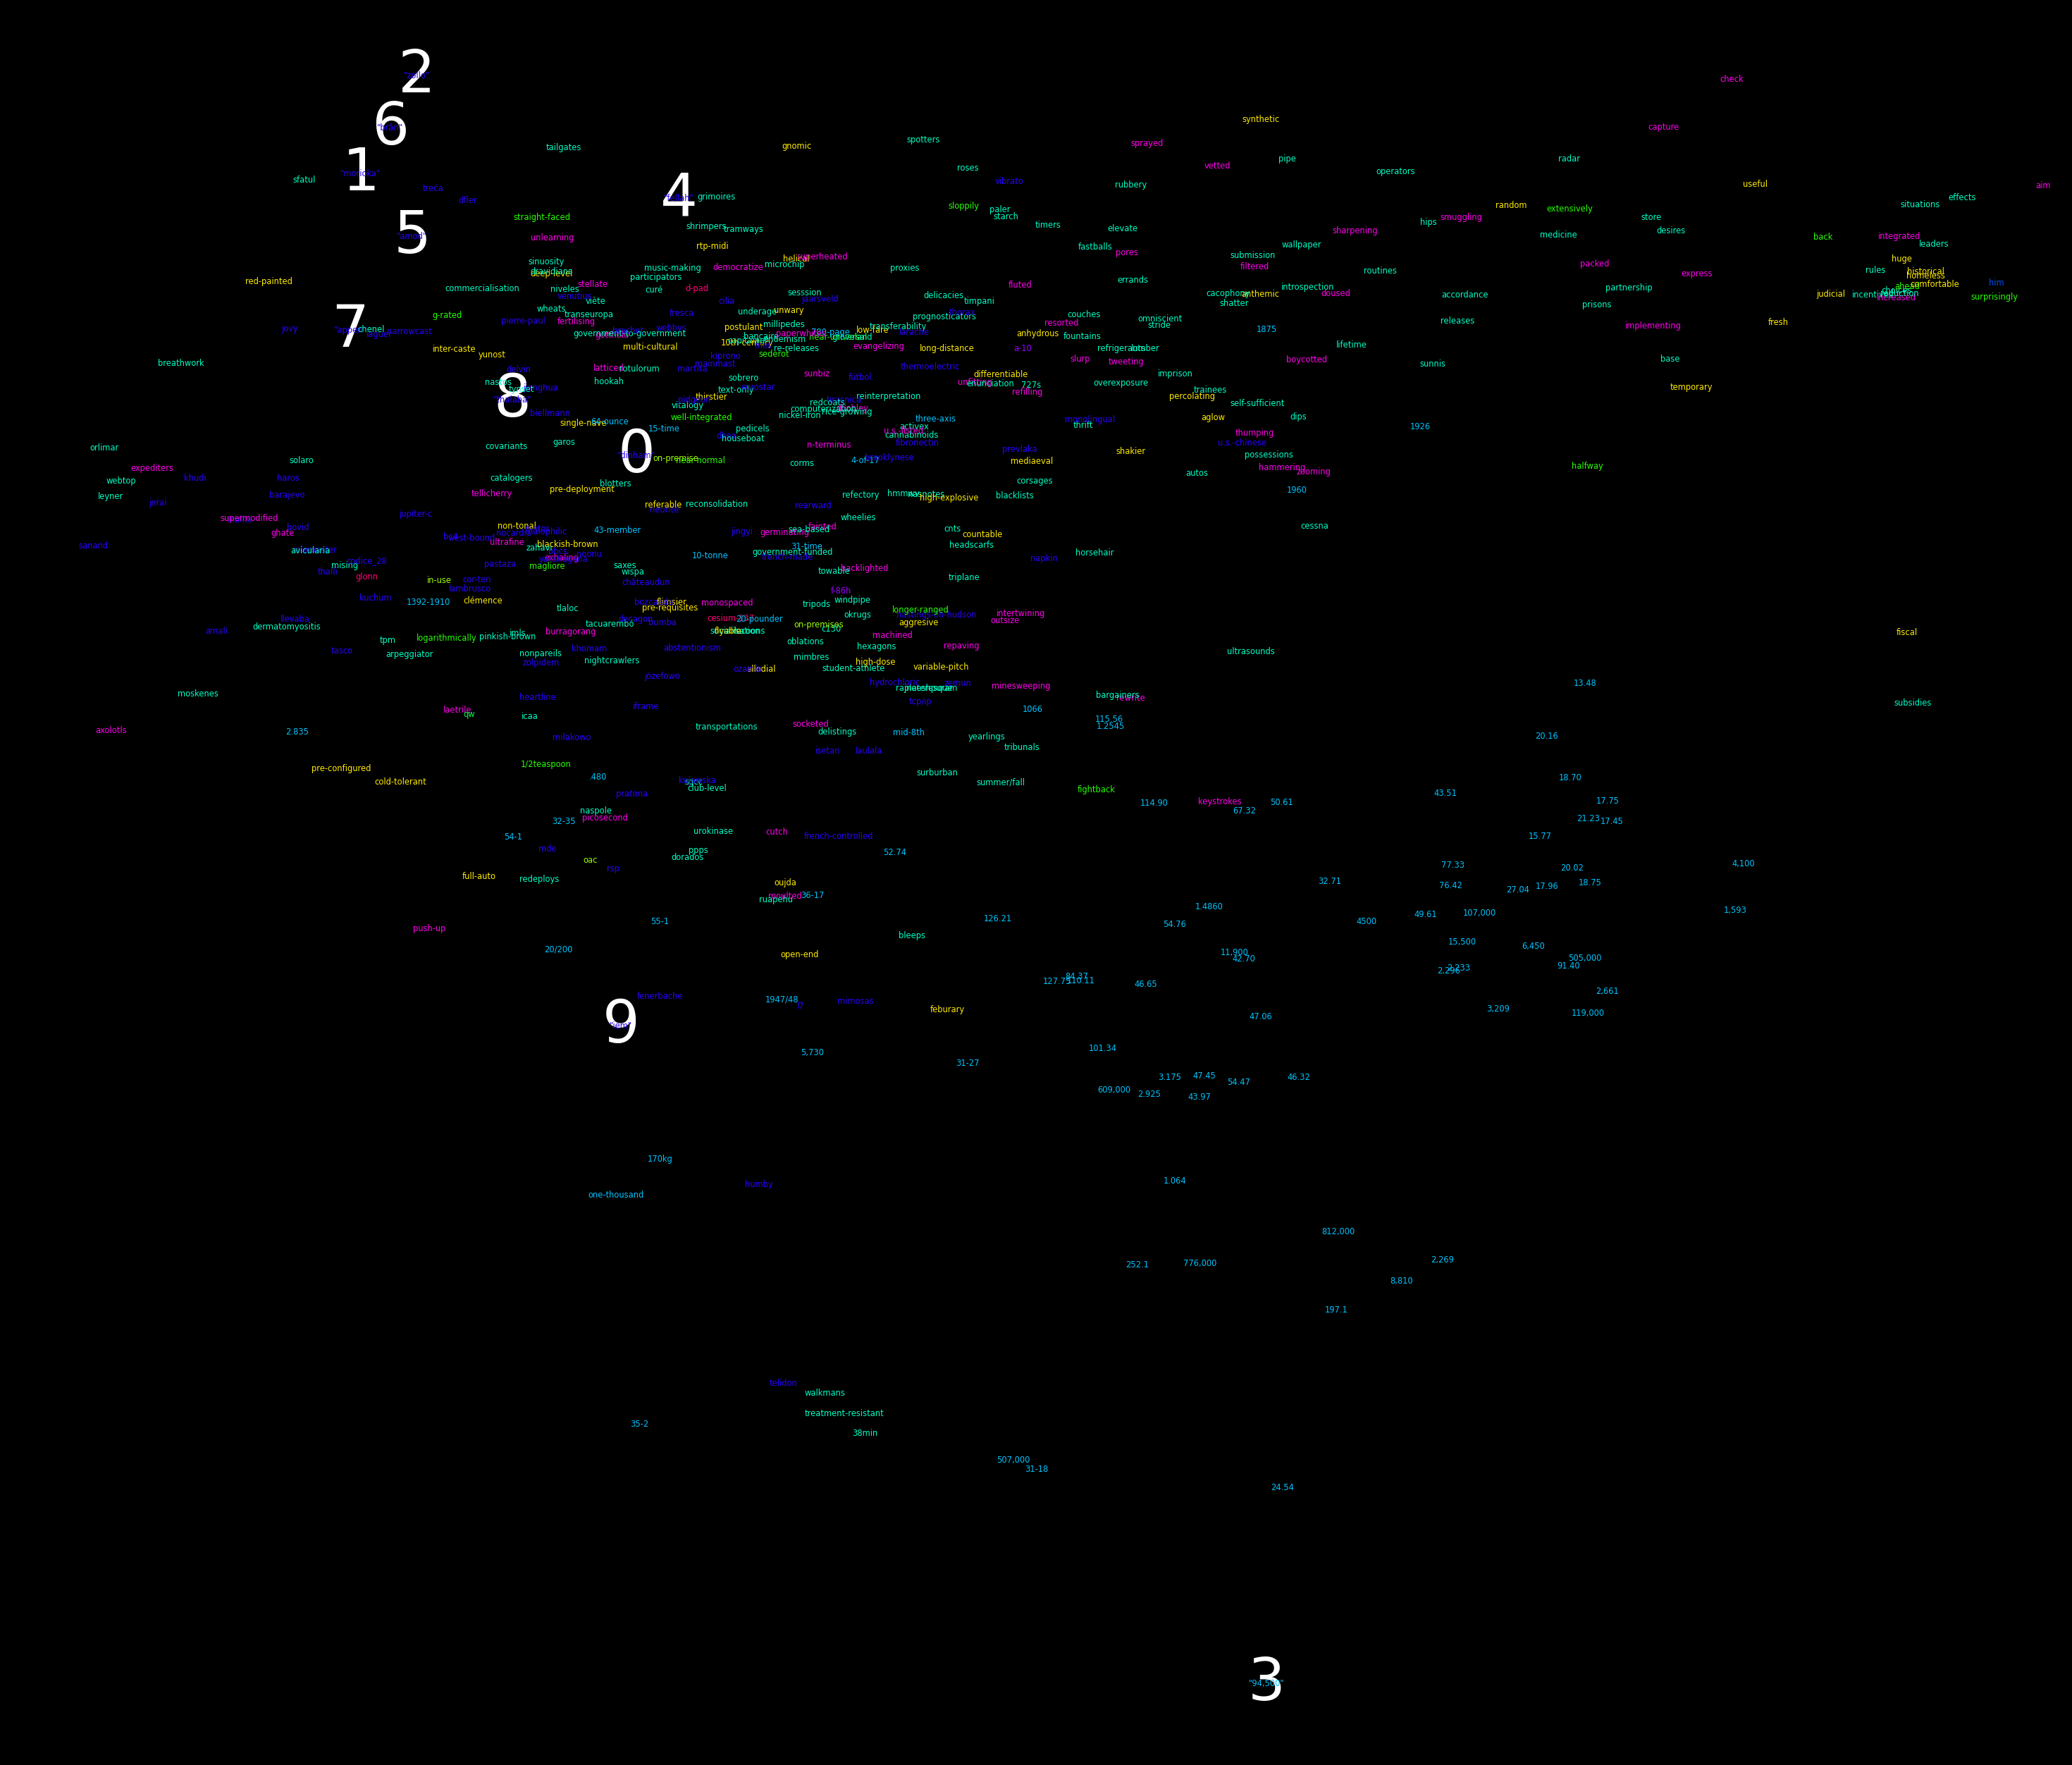

In [72]:
focus_on = np.array([0,1,2,3,4,5,6,7,8,9])
mnistVisuals.plot_points_from_file('../../Voltage_Data/glove/glove_5.csv', 500, points, centroids, voltages, label_counts, centroid_others, 
                                            focus_on=focus_on, element='word', size_threshold=0, ratio_threshold=0, percent_size=0.005)